Steps:
- get 100 year flood zones
- clip to far rockaway nta polygon
- get pluto endpoint (to apportion population to)
- proportional split census blocks to flood zones
- observe results
- then map in pluto by land use- see the uneven distribution of residential land use in flood zones
- then apportion population by residential units in pluto, and map that
- far rockaway nta polygon: https://data.cityofnewyork.us/resource/9nt8-h7nd.json?$query=SELECT%20borocode%2C%20boroname%2C%20countyfips%2C%20nta2020%2C%20ntaname%2C%20ntaabbrev%2C%20ntatype%2C%20cdta2020%2C%20cdtaname%2C%20shape_leng%2C%20shape_area%2C%20the_geom%20SEARCH%20%22far%22

In [34]:
%load_ext autoreload
%autoreload 2
from cdptools import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
import geopandas as gpd
import requests

In [36]:
utils.set_axis_off()

In [37]:
far_rockaway_gdf = gpd.read_file(
    "https://data.cityofnewyork.us/resource/9nt8-h7nd.geojson?$query=SELECT%20borocode%2C%20boroname%2C%20countyfips%2C%20nta2020%2C%20ntaname%2C%20ntaabbrev%2C%20ntatype%2C%20cdta2020%2C%20cdtaname%2C%20shape_leng%2C%20shape_area%2C%20the_geom%20SEARCH%20%22far%22"
)

In [38]:
flood_zones_2050_gdf = gpd.read_file(
    "/Users/marioag/Downloads/Future Floodplain 2050s_20260603/geo_export_fab09dc5-c2ff-49b9-8f9b-e38e1f1a652f.shp"
).to_crs(epsg=2263)

In [39]:
census_far_rockaway_gdf = gpd.read_file(
    "./Data/census_nyc_sp.fgb", where="zip_code = '11691'"
)

In [40]:
far_rockaway_gdf

,shape_area,ntaname,cdtaname,shape_leng,boroname,ntatype,nta2020,borocode,countyfips,ntaabbrev,cdta2020,geometry
0,60474867.0782,Far Rockaway-Bayswater,QN14 The Rockaways (CD 14 Approximation),48622.4860573,Queens,0,QN1401,4,081,FrRckwy,QN14,"MULTIPOLYGON (((-73.76964 40.59077, -73.76977 ..."


In [42]:
flood_zones_2050_gdf

,gridcode,join_count,fld_zone,static_bfe,abfe_0_2pc,shape_leng,shape_area,geometry
0,900.0,0.0,NaN,0.0,0.0,0.000000,0.000000e+00,"MULTIPOLYGON (((1009144.3 272810.675, 1009125...."
1,900.0,0.0,NaN,0.0,0.0,0.000000,0.000000e+00,"POLYGON ((1008744.3 272060.675, 1008720.365 27..."
2,1200.0,0.0,NaN,0.0,0.0,0.000000,0.000000e+00,"MULTIPOLYGON (((1009069.3 274539.23, 1008774.1..."
3,900.0,0.0,NaN,0.0,0.0,0.000000,0.000000e+00,"MULTIPOLYGON (((1008840.674 271774.301, 100884..."
4,1200.0,0.0,NaN,0.0,0.0,0.000000,0.000000e+00,"POLYGON ((1008137.926 271350.605, 1008109.693 ..."
...,...,...,...,...,...,...,...,...
10606,1300.0,8.0,VE,13.0,17.0,94503.216652,2.901814e+07,"POLYGON ((1024258.208 176855.005, 1024263.468 ..."
10607,1300.0,3.0,AE,12.0,17.0,7002.614257,1.095574e+06,"MULTIPOLYGON (((1024048.354 176962.134, 102398..."
10608,1300.0,8.0,VE,13.0,17.0,94503.216652,2.901814e+07,"MULTIPOLYGON (((1024048.354 176962.134, 102398..."
10609,1300.0,3.0,AE,12.0,17.0,7002.614257,1.095574e+06,"MULTIPOLYGON (((1024041.544 176962.598, 102404..."


In [43]:
base_url = "https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/arcgis/rest/services/MAPPLUTO/FeatureServer/0/query"
layer_wkid = 2263

all_features, offset = [], 0
while True:
    params = {
        "where": "ZipCode = 11691",
        "outFields": "CD,LandUse,UnitsRes,BCTCB2020,BCT2020",
        "returnGeometry": "true",
        "outSR": layer_wkid,
        "resultOffset": offset,
        "resultRecordCount": 2000,
        "f": "geojson",
    }
    r = requests.get(base_url, params=params)
    r.raise_for_status()
    fc = r.json()
    if "error" in fc:
        raise RuntimeError(fc["error"])
    feats = fc.get("features", [])
    all_features.extend(feats)
    if len(feats) < 2000:
        break
    offset += 2000

In [44]:
far_rockaway_pluto_gdf = gpd.GeoDataFrame.from_features(
    all_features, crs=f"EPSG:{layer_wkid}"
)

In [46]:
census_far_rockaway_gdf["bg_area"] = census_far_rockaway_gdf.geometry.area
census_far_rockaway_gdf["flooded_area 2050"] = (
    census_far_rockaway_gdf.geometry.intersection(flood_zones_2050_gdf.union_all()).area
)
census_far_rockaway_gdf["frac_flooded_2050"] = (
    census_far_rockaway_gdf["flooded_area 2050"] / census_far_rockaway_gdf["bg_area"]
)

In [47]:
census_far_rockaway_gdf["pop_in_flood_zone_2050"] = (
    census_far_rockaway_gdf["Total Pop (Race/Ethnicity)"]
    * census_far_rockaway_gdf["frac_flooded_2050"]
)

<Axes: >

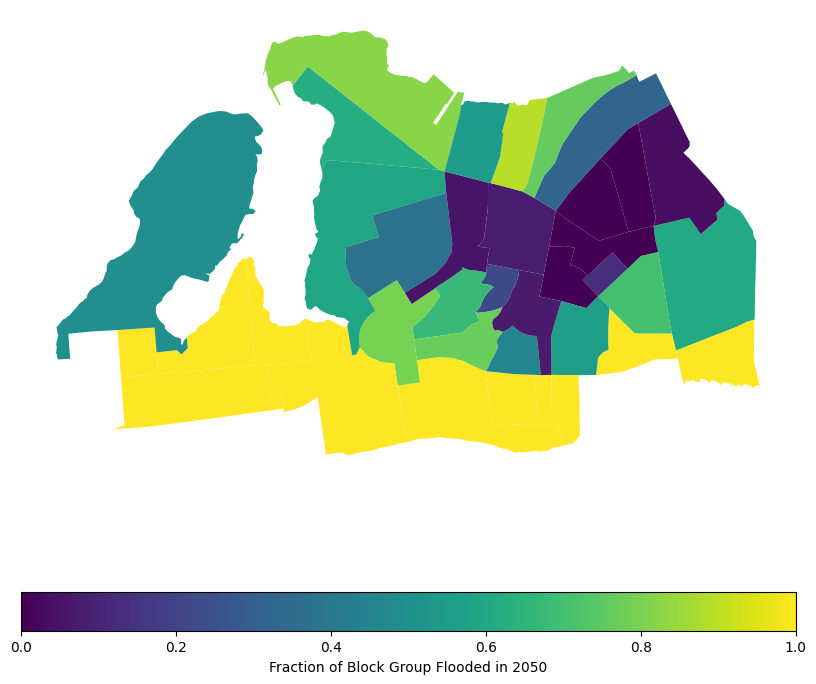

In [101]:
census_far_rockaway_gdf.plot(
    column="frac_flooded_2050",
    legend=True,
    figsize=(10, 10),
    legend_kwds={
        "label": "Fraction of Block Group Flooded in 2050",
        "orientation": "horizontal",
    },
)

<Axes: >

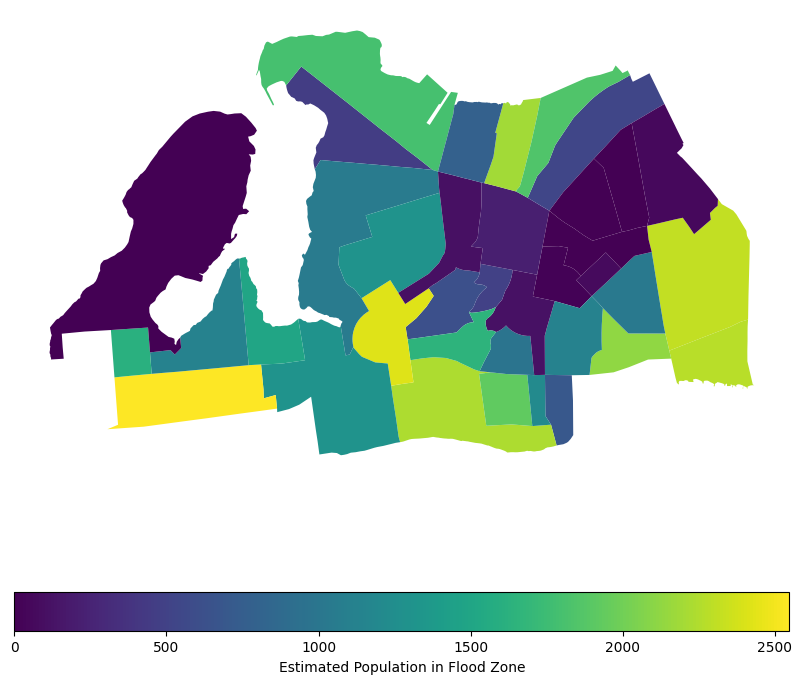

In [100]:
census_far_rockaway_gdf.plot(
    column="pop_in_flood_zone_2050",
    legend=True,
    figsize=(10, 10),
    legend_kwds={
        "label": "Estimated Population in Flood Zone",
        "orientation": "horizontal",
    },
)

In [50]:
census_far_rockaway_gdf["pop_points"] = census_far_rockaway_gdf.apply(
    lambda row: utils.random_points_in_geom(
        row.geometry, row["Total Pop (Race/Ethnicity)"] / 10
    ),
    axis=1,
)

Text(0.5, 1.0, 'Randomly distributed population points in Far Rockaway')

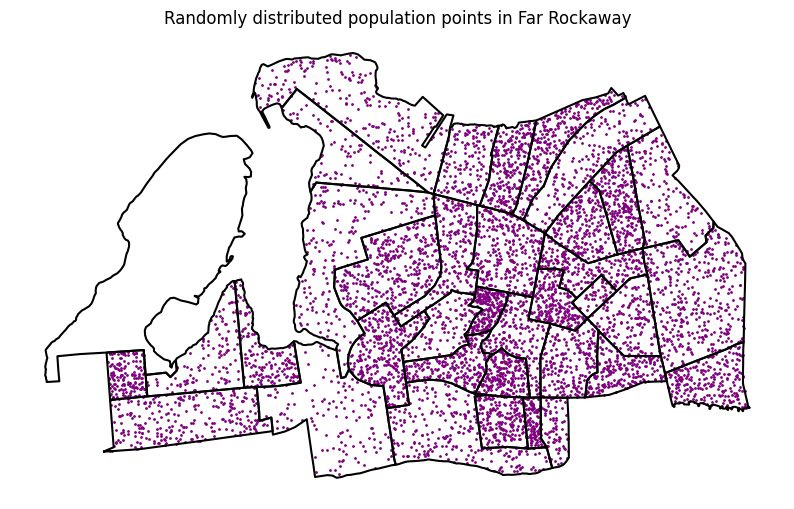

In [62]:
ax = census_far_rockaway_gdf.boundary.plot(color="black", figsize=(10, 10))
census_far_rockaway_gdf.set_geometry("pop_points").plot(
    ax=ax, color="purple", markersize=1
)
ax.set_title("Randomly distributed population points in Far Rockaway")

That representation does well to show the relative population density within each block group, assuming that the population in each is evenly distributed. Per our assumption on the proportional distribution, we would assume that the area coverage for each block group is proportional to the population, so the more area covered by a flood zone, the more population is affected. This is a common assumption in spatial analysis when we don't have more granular data on population distribution. However, it's important to note that this assumption may not always hold true, as population density can vary significantly within block groups, *especially* when dealing with dense urban areas. Luckily MapPLUTO indicates the number of residential units in each tax lot, so we can use that to apportion population more accurately.

In [52]:
far_rockaway_pluto_gdf[far_rockaway_pluto_gdf.BCT2020 == "4103201"].BCTCB2020.unique()

<ArrowStringArray>
['41032013001', '41032013000', '41032013004', '41032013006', '41032013005',
 '41032012001', '41032012002', '41032012003', '41032011001', '41032011002',
 '41032011003', '41032012006', '41032012007', '41032012005', '41032012004',
 '41032011006', '41032011005', '41032011004', '41032013002', '41032013003',
 '41032012000']
Length: 21, dtype: str

In [53]:
far_rockaway_pluto_gdf["block_group"] = far_rockaway_pluto_gdf["BCTCB2020"].str[1:8]

In [54]:
far_rockaway_pluto_gdf["block_group"].unique()

<ArrowStringArray>
['1032013', '1032021',       nan, '1032022', '1032023', '1032024', '1010031',
 '1010033', '1010021', '1010032', '1010042', '1010022', '1010043', '1010041',
 '0998013', '1010045', '1010044', '1032012', '1032011', '1008012', '1008011',
 '1008031', '1008032', '1008042', '1008041', '0992001', '0998012', '0998011',
 '0998015', '0998014', '0998021', '0998022', '0998023', '0992002', '0972041',
 '0972021', '0972061', '0972062', '0972071', '0972052']
Length: 40, dtype: str

In [55]:
census_far_rockaway_gdf["block_group"] = census_far_rockaway_gdf["GISJOIN"].str[8:]

Now we need to match the tax lots in MapPLUTO to the block groups in the census data on the new ID we created. We will apportion the population in each block group to the tax lots based on the number of residential units in each lot. This way, we can get a more accurate representation of how many people are affected by the flood zones, rather than assuming an even distribution across the block group.

In [56]:
def apportion_population_to_tax_lot(row, pluto_gdf, census_gdf):
    """Apportion population in a census block group to tax lots based on the number of residential units.
    returns the population per tax lot
    """
    block_group = row["block_group"]
    # get total pop from the census gdf
    if block_group not in census_gdf["block_group"].values:
        return 0
    population = census_gdf[census_gdf["block_group"] == block_group][
        "Total Pop (Race/Ethnicity)"
    ].values[0]
    pluto_subset = pluto_gdf[pluto_gdf["block_group"] == block_group]
    total_units = pluto_subset["UnitsRes"].sum()
    if total_units == 0:
        return 0
    row["pop_apportioned"] = row["UnitsRes"] / total_units * population
    return row["pop_apportioned"]

In [57]:
far_rockaway_pluto_gdf["est_pop_per_lot"] = far_rockaway_pluto_gdf.apply(
    lambda row: apportion_population_to_tax_lot(
        row, far_rockaway_pluto_gdf, census_far_rockaway_gdf
    ),
    axis=1,
)

<Axes: >

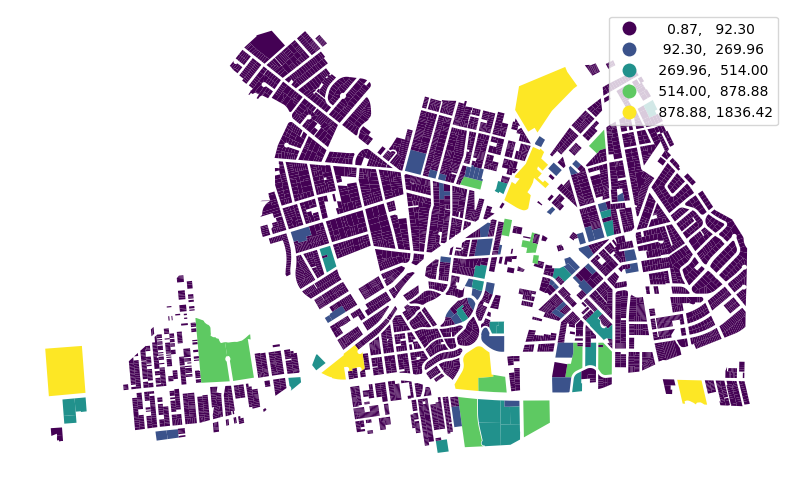

In [98]:
far_rockaway_pluto_gdf[far_rockaway_pluto_gdf.est_pop_per_lot.gt(0)].plot(
    column="est_pop_per_lot",
    legend=True,
    scheme="naturalbreaks",
    figsize=(10, 10),
)
# put legend in upper left corner

In [78]:
far_rockaway_pluto_gdf["pop_points"] = far_rockaway_pluto_gdf.apply(
    lambda row: (
        utils.random_points_in_geom(row.geometry, row["est_pop_per_lot"] / 2)
        if row["est_pop_per_lot"] > 0
        else None
    ),
    axis=1,
)

<Axes: >

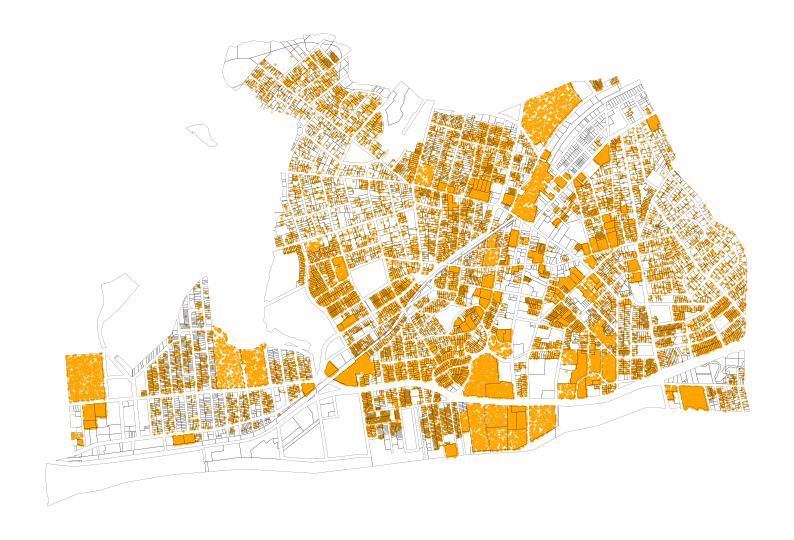

In [93]:
ax = far_rockaway_pluto_gdf.boundary.plot(
    color="black", linewidth=0.1, figsize=(10, 10)
)
far_rockaway_pluto_gdf.set_geometry("pop_points").plot(
    color="orange", markersize=0.5, legend=True, ax=ax
)

Now we have a much more precise view of where residents are located within the flood zones, which can help us better understand the potential impact of flooding on the community. We can see that certain areas within the flood zones have a higher concentration of residential units, which indicates that more people may be affected in those areas compared to others with fewer residential units. Now we can take another look at the residents in the flood zones, but this time with a more accurate representation of where people actually live, rather than just assuming an even distribution across the block groups.

Text(0.5, 1.0, 'Estimated Population in 2050 Flood Zone per Block Group (PLUTO-weighted)')

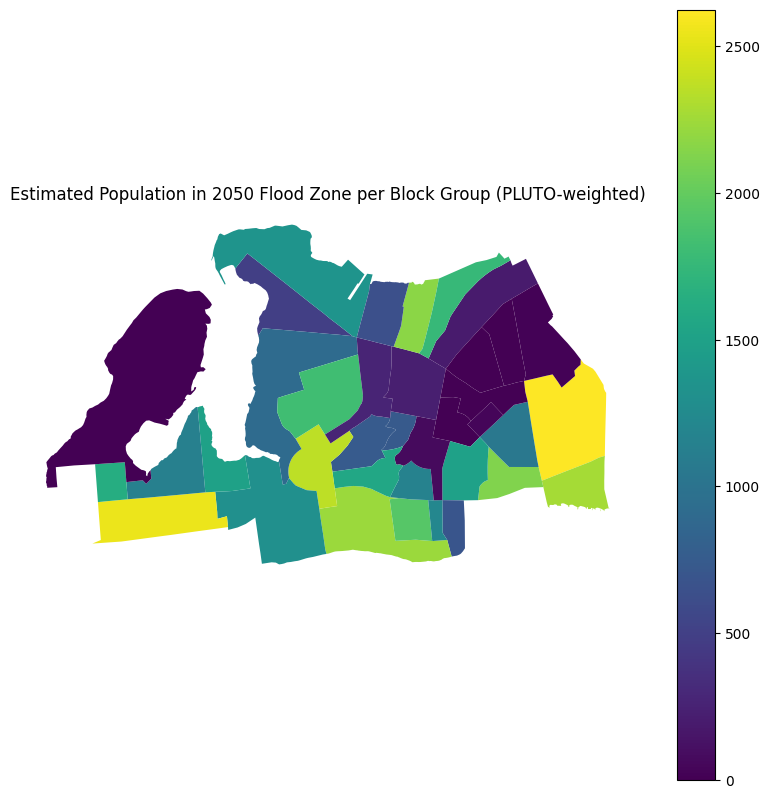

In [ ]:
# Intersect flood zones with pluto lots, and then group by block group to get a pop in flood zone per block group, then merge that back to the pluto lots to get a pop in flood zone per lot, then map that.
# Intersect flood zones with pluto lots
flood_union = flood_zones_2050_gdf.union_all()

pluto_in_flood = far_rockaway_pluto_gdf.copy()
pluto_in_flood["lot_area"] = pluto_in_flood.geometry.area
pluto_in_flood["flooded_area"] = pluto_in_flood.geometry.intersection(flood_union).area
pluto_in_flood["frac_flooded"] = (
    pluto_in_flood["flooded_area"] / pluto_in_flood["lot_area"]
)

# Apportion estimated population in flood zone per lot
pluto_in_flood["est_pop_in_flood"] = (
    pluto_in_flood["est_pop_per_lot"] * pluto_in_flood["frac_flooded"]
)

# Group by block group to get total pop in flood zone per block group
bg_flood_pop = (
    pluto_in_flood.groupby("block_group")["est_pop_in_flood"]
    .sum()
    .reset_index()
    .rename(columns={"est_pop_in_flood": "bg_pop_in_flood_pluto"})
)

# Merge back to census block groups for comparison
census_far_rockaway_gdf = census_far_rockaway_gdf.merge(
    bg_flood_pop, on="block_group", how="left"
)
census_far_rockaway_gdf["bg_pop_in_flood_pluto"] = census_far_rockaway_gdf[
    "bg_pop_in_flood_pluto"
].fillna(0)



Text(0.5, 1.0, 'Estimated Population in 2050 Flood Zone per Block Group (PLUTO-weighted)')

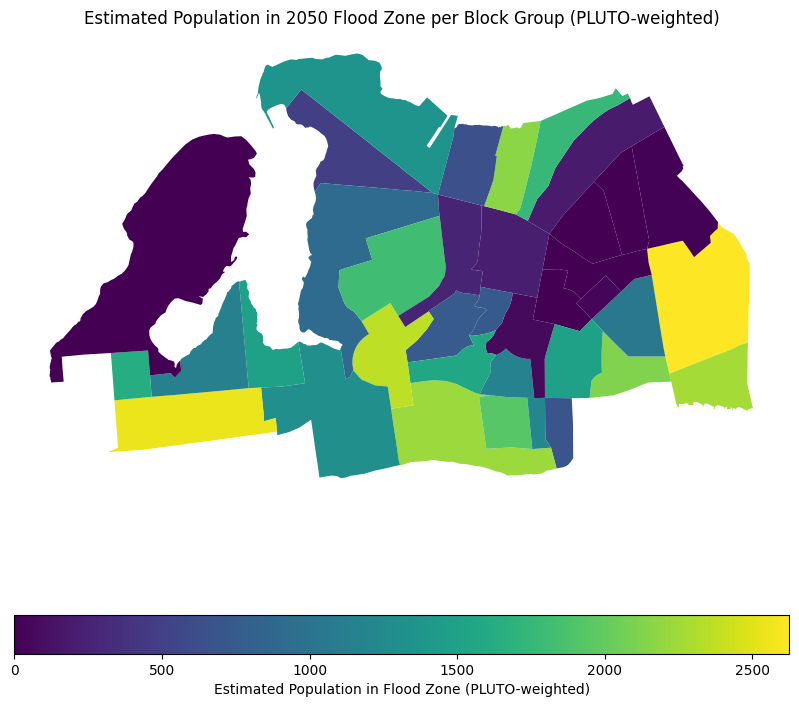

In [92]:
# Map the result
ax = census_far_rockaway_gdf.plot(
    column="bg_pop_in_flood_pluto",
    legend=True,
    figsize=(10, 10),
    legend_kwds={
        "label": "Estimated Population in Flood Zone (PLUTO-weighted)",
        "orientation": "horizontal",
    },
)
ax.set_title("Estimated Population in 2050 Flood Zone per Block Group (PLUTO-weighted)")

In [60]:
# get the difference between the two estimates
census_far_rockaway_gdf["pop_diff"] = (
    census_far_rockaway_gdf["pop_in_flood_zone_2050"]
    - census_far_rockaway_gdf["bg_pop_in_flood_pluto"]
)

Now we can see the difference between the two estimates, which shows us how much our estimate of population in the flood zones has changed by using the proportional split method with MapPLUTO data. This can help us understand the potential impact of flooding on the community more accurately, and can inform better decision-making for flood mitigation and emergency response planning. The negative values in the difference map below indicate cases where the proportional split estimated fewer people in the flood zones compared to the even distribution method, while positive values indicate cases where the proportional split estimated more people in the flood zones. This highlights the importance of using more granular data and methods to get a more accurate picture of vulnerability to flooding.

In [82]:
import matplotlib.pyplot as plt

<Axes: >

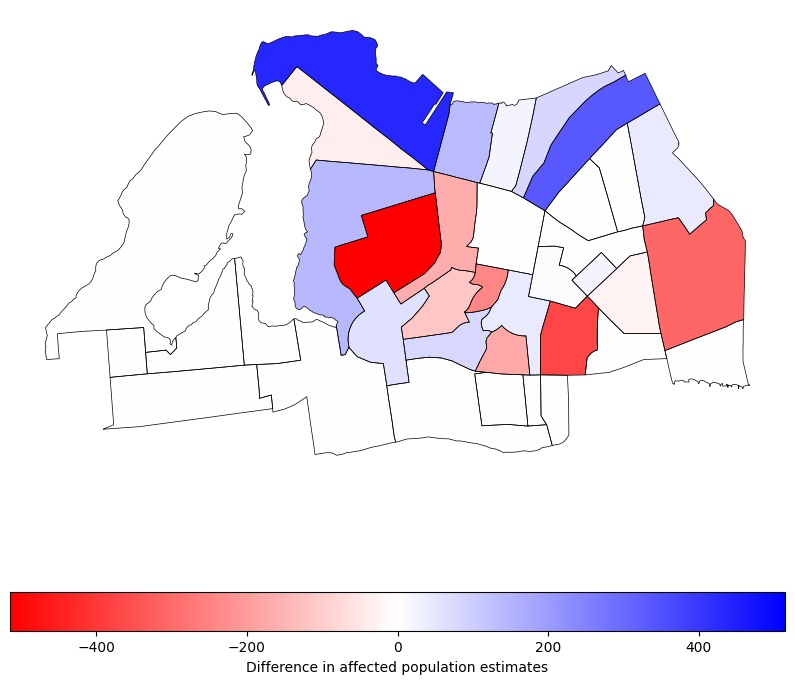

In [91]:
ax = census_far_rockaway_gdf.boundary.plot(
    edgecolor="black", figsize=(10, 10), linewidth=0.5
)
census_far_rockaway_gdf.plot(
    "pop_diff",
    legend=True,
    cmap="bwr_r",
    vmin=-census_far_rockaway_gdf["pop_diff"].abs().max(),
    vmax=census_far_rockaway_gdf["pop_diff"].abs().max(),
    legend_kwds={
        "label": "Difference in affected population estimates",
        "orientation": "horizontal",
    },
    ax=ax,
)